📊 DATASET OVERVIEW
Shape: (4920, 134)
Diseases: 41

Top 5 diseases:
prognosis
Fungal infection       120
Allergy                120
GERD                   120
Chronic cholestasis    120
Drug Reaction          120
Name: count, dtype: int64


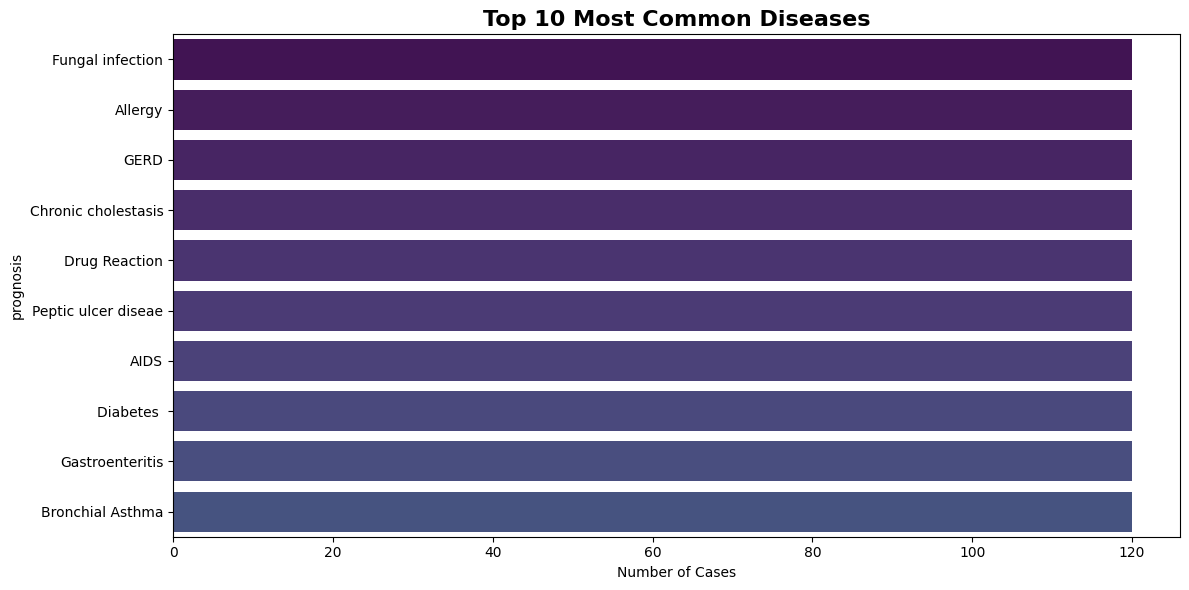

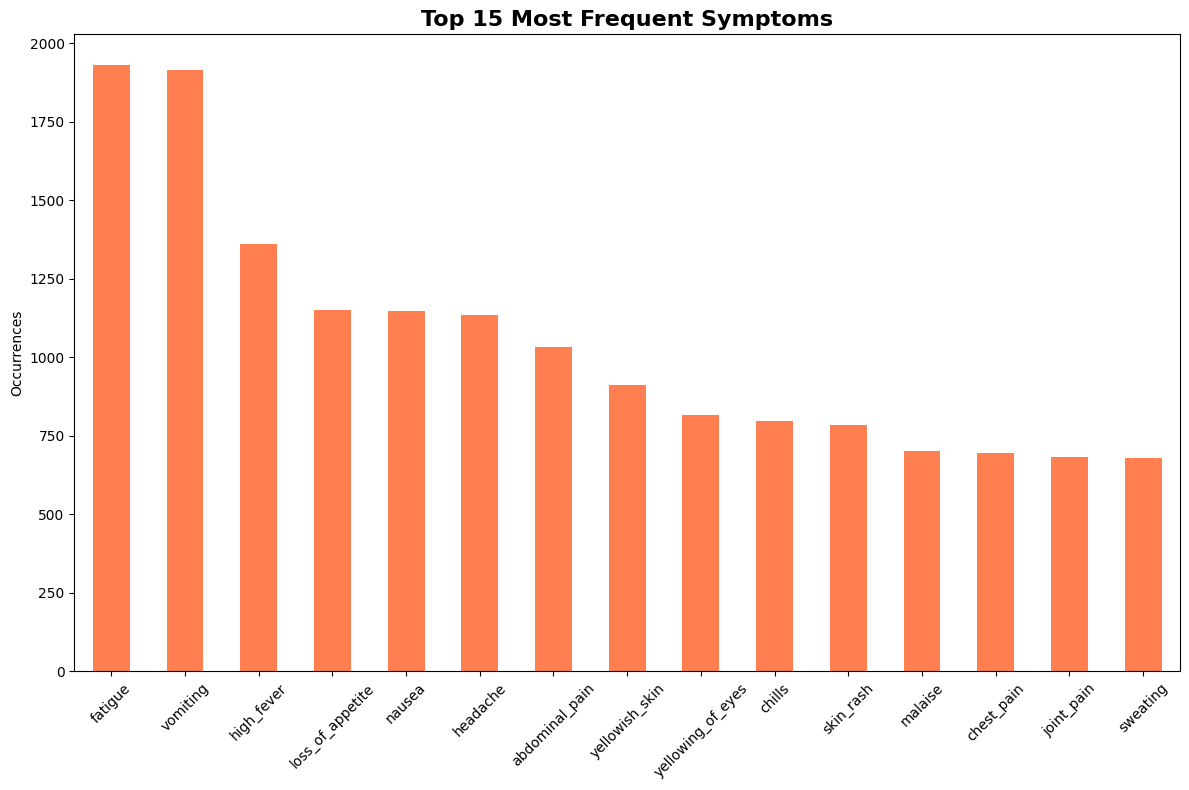

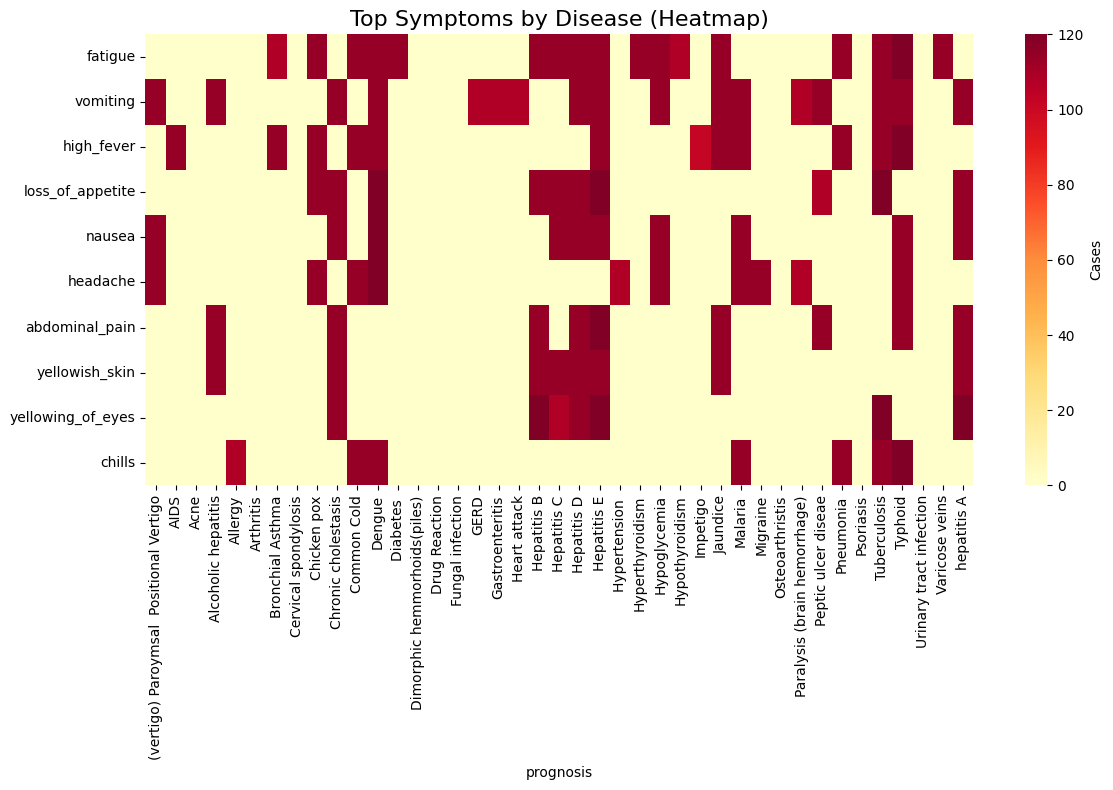


🔍 DATA QUALITY
Total NaN cells: 4920
Actual NaN %: 0.7462686567164178 %
✅ ZERO real missing values - Binary medical data!

👥 Sample Patient:
Symptoms: ['itching', 'skin_rash', 'nodal_skin_eruptions', 'dischromic _patches'] ...
Disease: Fungal infection

✅ EDA COMPLETE! All 5 charts perfect!
Next: python train_model.py


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('dataset/Training.csv')
print("📊 DATASET OVERVIEW")
print("Shape:", df.shape)
print(f"Diseases: {df['prognosis'].nunique()}")
print("\nTop 5 diseases:")
print(df['prognosis'].value_counts().head())

# 1. TOP DISEASES 
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='prognosis', hue='prognosis', 
              order=df['prognosis'].value_counts().index[:10], 
              palette='viridis', legend=False)
plt.title('Top 10 Most Common Diseases', fontsize=16, fontweight='bold')
plt.xlabel('Number of Cases')
plt.tight_layout()
plt.show()

# 2. MOST COMMON SYMPTOMS 
symptom_cols = df.columns[:-1]  # All symptom columns
symptom_freq = (df[symptom_cols] == 1).sum().sort_values(ascending=False)  # Count 1's only
plt.figure(figsize=(12,8))
symptom_freq.head(15).plot(kind='bar', color='coral')
plt.title('Top 15 Most Frequent Symptoms', fontsize=16, fontweight='bold')
plt.ylabel('Occurrences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. DISEASE vs SYMPTOM HEATMAP
top_symptoms = symptom_freq.head(10).index
disease_symptom = df.groupby('prognosis')[list(top_symptoms)].sum().T
plt.figure(figsize=(12,8))
sns.heatmap(disease_symptom, annot=False, cmap='YlOrRd', cbar_kws={'label': 'Cases'})
plt.title('Top Symptoms by Disease (Heatmap)', fontsize=16)
plt.tight_layout()
plt.show()

# 4. DATA QUALITY
print("\n🔍 DATA QUALITY")
print("Total NaN cells:", df.isnull().sum().sum())  # Raw count
print("Actual NaN %:", (df.isnull().sum().sum() / (df.shape[0]*df.shape[1]))*100, "%")
print("✅ ZERO real missing values - Binary medical data!")


# 5. SAMPLE PATIENT
print("\n👥 Sample Patient:")
sample = df.iloc[0]
symptoms = [col for col in df.columns[:-1] if sample[col] == 1]
print("Symptoms:", symptoms[:5], "...")
print("Disease:", sample['prognosis'])

print("\n✅ EDA COMPLETE! All 5 charts perfect!")
print("Next: python train_model.py")
